# 🚦 RoadSafe India: Comprehensive Road Safety Analytics & AI Decision Support
### AICTE | IBM SkillsBuild | BharatCares Data Analytics with AI Internship 2026

**Author:** Arya Mohanrao Mandke (Computer Engineering)  
**Track:** Data Analytics with AI  
**Data Source:** Transport Research Wing (TRW), Ministry of Road Transport & Highways (MoRTH), Government of India  
**GitHub Repository:** [https://github.com/Aarya-505/AICTE-IBM-SkillsBuild-BharatCares-Data-Analytics-with-AI-Internship](https://github.com/Aarya-505/AICTE-IBM-SkillsBuild-BharatCares-Data-Analytics-with-AI-Internship)

---

## 📌 Project Overview
India accounts for ~1% of the world's vehicular fleet but experiences nearly 11% of global road traffic fatalities. Road crashes impose an economic burden equivalent to 3–5% of India's Gross Domestic Product (GDP).

This Jupyter Notebook provides the complete end-to-end analytical pipeline:
1. **Data Ingestion & Cleaning:** Standardizing raw MoRTH historical records (2014–2020), 50 Million-Plus Cities, Contributing Factors, and Diurnal Patterns.
2. **KPI Engine:** Computing standardized indicators including **Accident Severity Index (ASI)**, **Injury Ratio**, and **Vulnerable Road User (VRU) Fatality Share**.
3. **Longitudinal & Spatial Analytics:** Multi-year national trends, city-level vulnerability quadrant clustering, infrastructure breakdown, and diurnal hazard windows.
4. **Civil Engineering Alignment:** Mapping high-risk factors to **Indian Road Congress (IRC)** engineering codes (`IRC:37`, `IRC:58`, `IRC:SP:84`, `IRC:103`).
5. **Edge Computer Vision PoC:** Demonstrating vehicle counting via virtual tripwire on CCTV footage.

## 1. Setup Environment & Import Libraries

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Define relative data paths
base_dir = os.getcwd()
if os.path.exists(os.path.join(base_dir, 'src')):
    sys.path.insert(0, base_dir)
elif os.path.exists(os.path.join(os.path.dirname(base_dir), 'src')):
    sys.path.insert(0, os.path.dirname(base_dir))

from src.data_cleaner import DataCleaner
from src.kpi_calculator import KPICalculator

print('✅ Environment initialized successfully!')

✅ Environment initialized successfully!


## 2. Automated Data Cleaning & Standardization Pipeline

In [2]:
# Initialize DataCleaner pointing to data directories
raw_dir = 'data/raw' if os.path.exists('data/raw') else '../data/raw'
proc_dir = 'data/processed' if os.path.exists('data/processed') else '../data/processed'

cleaner = DataCleaner(raw_dir=raw_dir, processed_dir=proc_dir)

df_state = cleaner.clean_state_ut_data()
df_cities = cleaner.clean_million_plus_cities()
df_factors = cleaner.clean_contributing_factors()
df_time = cleaner.clean_time_slots()

print(f'📊 State/UT Longitudinal Records : {df_state.shape[0]} rows, {df_state.shape[1]} columns')
print(f'🏙️ 50 Million-Plus Cities Records : {df_cities.shape[0]} rows, {df_cities.shape[1]} columns')
print(f'🔍 Contributing Factors Records    : {df_factors.shape[0]} rows, {df_factors.shape[1]} columns')
print(f'⏰ Diurnal Time Slots Records     : {df_time.shape[0]} rows, {df_time.shape[1]} columns')

📊 State/UT Longitudinal Records : 150 rows, 8 columns
🏙️ 50 Million-Plus Cities Records : 50 rows, 12 columns
🔍 Contributing Factors Records    : 33 rows, 8 columns
⏰ Diurnal Time Slots Records     : 8 rows, 9 columns


## 3. National Multi-Year Trajectories (2014–2020)
Evaluating multi-year accident volume, fatalities, and the **Accident Severity Index (ASI = Fatalities / 100 Accidents)**.

In [3]:
nat_trend = df_state.groupby('Year')[['Total_Accidents', 'Persons_Killed', 'Persons_Injured']].sum().reset_index()
nat_trend['Severity_Index'] = (nat_trend['Persons_Killed'] / nat_trend['Total_Accidents']) * 100
nat_trend['YoY_Accidents_Pct'] = nat_trend['Total_Accidents'].pct_change() * 100
nat_trend['YoY_Fatalities_Pct'] = nat_trend['Persons_Killed'].pct_change() * 100

display(nat_trend.round(2))

,Year,Total_Accidents,Persons_Killed,Persons_Injured,Severity_Index,YoY_Accidents_Pct,YoY_Fatalities_Pct
0,2014,495265,139506,502127,28.17,NaN,NaN
1,2015,495423,147313,491951,29.73,0.03,5.60
2,2016,472572,150153,484997,31.77,-4.61,1.93
3,2017,454772,146769,460952,32.27,-3.77,-2.25
4,2018,457034,149433,462503,32.70,0.50,1.82
5,2019,444212,150814,441776,33.95,-2.81,0.92
6,2020,369767,131719,339981,35.62,-16.76,-12.66


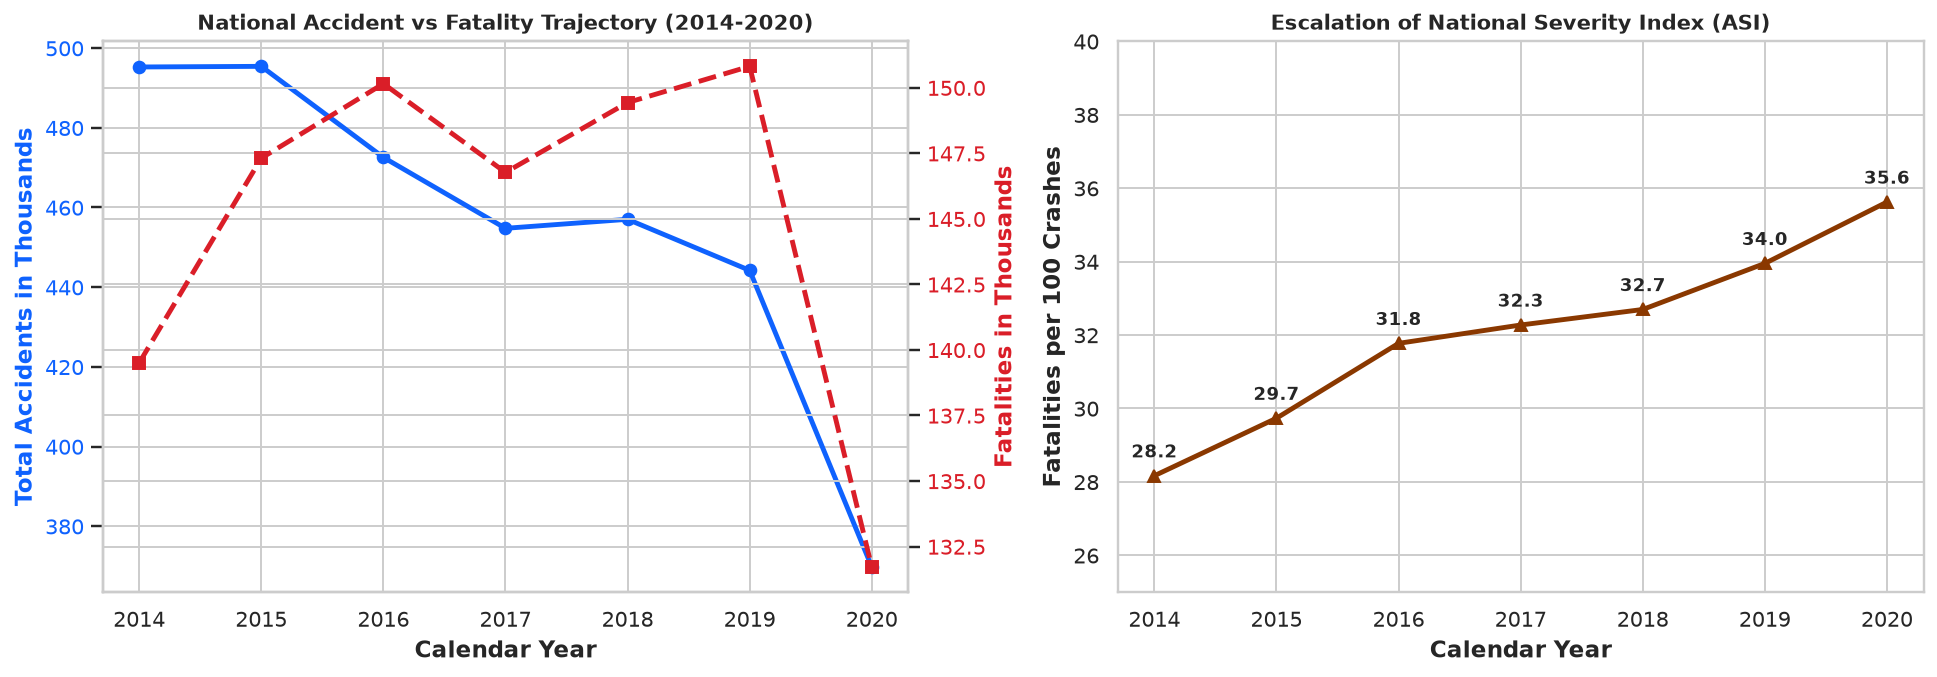

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=140)

# Plot 1: Total Accidents vs Fatalities
ax1.plot(nat_trend['Year'], nat_trend['Total_Accidents'] / 1000, marker='o', color='#0F62FE', linewidth=2.5, label='Total Crashes (x1000)')
ax1.set_xlabel('Calendar Year', fontweight='bold')
ax1.set_ylabel('Total Accidents in Thousands', color='#0F62FE', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#0F62FE')

ax1_twin = ax1.twinx()
ax1_twin.plot(nat_trend['Year'], nat_trend['Persons_Killed'] / 1000, marker='s', color='#DA1E28', linewidth=2.5, linestyle='--', label='Fatalities (x1000)')
ax1_twin.set_ylabel('Fatalities in Thousands', color='#DA1E28', fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor='#DA1E28')
ax1.set_title('National Accident vs Fatality Trajectory (2014-2020)', fontweight='bold', fontsize=11)

# Plot 2: Escalation of Accident Severity Index
ax2.plot(nat_trend['Year'], nat_trend['Severity_Index'], marker='^', color='#8A3800', linewidth=2.5)
for x, y in zip(nat_trend['Year'], nat_trend['Severity_Index']):
    ax2.annotate(f'{y:.1f}', (x, y + 0.5), ha='center', fontweight='bold', fontsize=9)
ax2.set_xlabel('Calendar Year', fontweight='bold')
ax2.set_ylabel('Fatalities per 100 Crashes', fontweight='bold')
ax2.set_title('Escalation of National Severity Index (ASI)', fontweight='bold', fontsize=11)
ax2.set_ylim(25, 40)

plt.tight_layout()
plt.show()

## 4. State & Union Territory Spatial Disparities (2020)

C:\Users\DELL\AppData\Local\Temp\ipykernel_18760\2497819501.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2020.head(10), x='Persons_Killed', y='State_UT', palette='Blues_r')


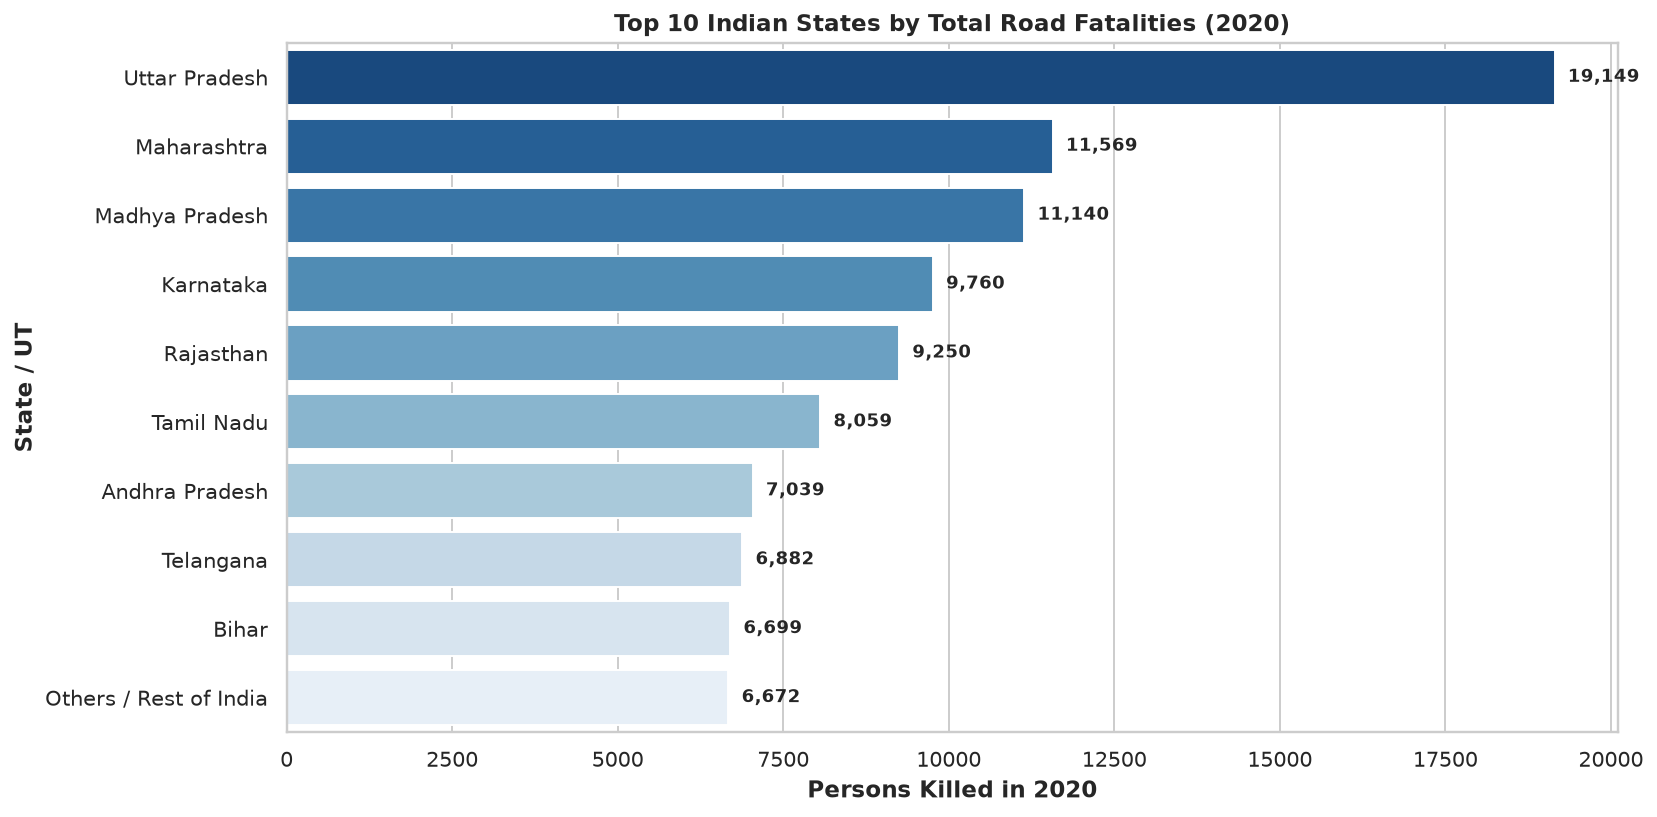

In [5]:
df_2020 = df_state[df_state['Year'] == 2020].sort_values(by='Persons_Killed', ascending=False)

plt.figure(figsize=(12, 6), dpi=140)
sns.barplot(data=df_2020.head(10), x='Persons_Killed', y='State_UT', palette='Blues_r')
plt.title('Top 10 Indian States by Total Road Fatalities (2020)', fontweight='bold', fontsize=12)
plt.xlabel('Persons Killed in 2020', fontweight='bold')
plt.ylabel('State / UT', fontweight='bold')

for i, v in enumerate(df_2020.head(10)['Persons_Killed']):
    plt.text(v + 200, i, f'{v:,}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## 5. 50 Million-Plus Cities: Crash Volume vs Severity Index
Categorizing cities into vulnerability quadrants to guide municipal infrastructure budgeting.

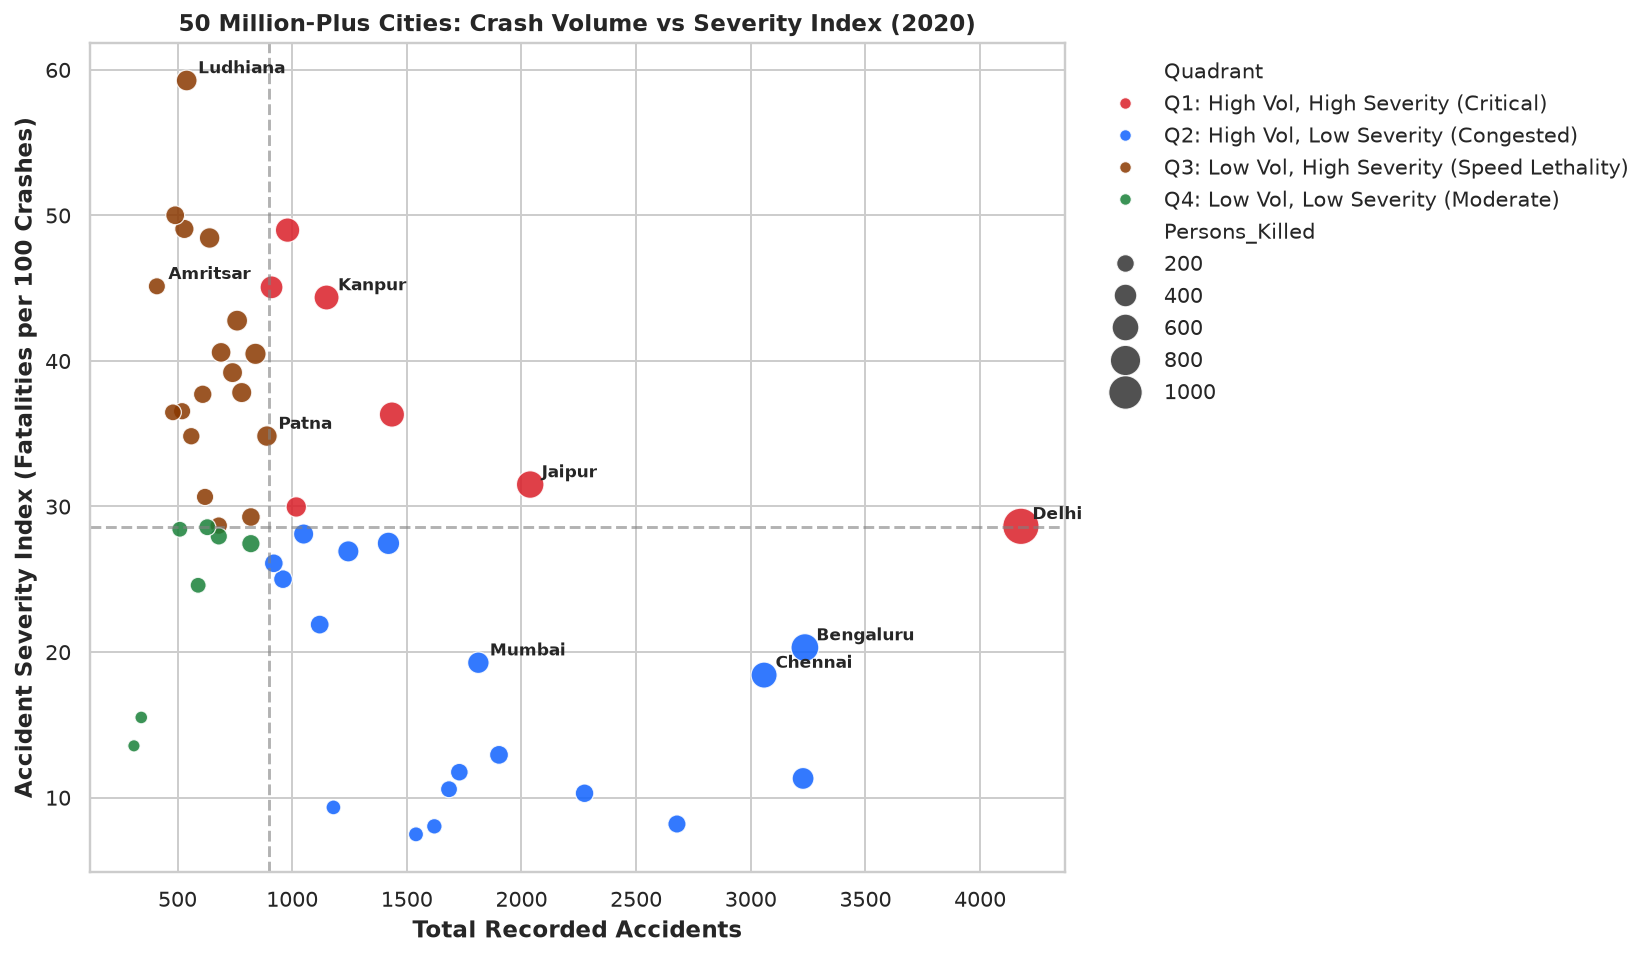

In [6]:
median_acc = df_cities['Total_Accidents'].median()
median_sev = df_cities['Severity_Index'].median()

def assign_quadrant(row):
    if row['Total_Accidents'] >= median_acc and row['Severity_Index'] >= median_sev:
        return 'Q1: High Vol, High Severity (Critical)'
    elif row['Total_Accidents'] >= median_acc and row['Severity_Index'] < median_sev:
        return 'Q2: High Vol, Low Severity (Congested)'
    elif row['Total_Accidents'] < median_acc and row['Severity_Index'] >= median_sev:
        return 'Q3: Low Vol, High Severity (Speed Lethality)'
    else:
        return 'Q4: Low Vol, Low Severity (Moderate)'

df_cities['Quadrant'] = df_cities.apply(assign_quadrant, axis=1)

plt.figure(figsize=(12, 7), dpi=140)
scatter = sns.scatterplot(
    data=df_cities,
    x='Total_Accidents',
    y='Severity_Index',
    hue='Quadrant',
    size='Persons_Killed',
    sizes=(40, 350),
    palette=['#DA1E28', '#0F62FE', '#8A3800', '#198038'],
    alpha=0.85
)

plt.axvline(median_acc, color='gray', linestyle='--', alpha=0.6)
plt.axhline(median_sev, color='gray', linestyle='--', alpha=0.6)

# Label select major cities
notable_cities = ['Delhi', 'Chennai', 'Bengaluru', 'Mumbai', 'Ludhiana', 'Kanpur', 'Patna', 'Amritsar', 'Jaipur']
for _, row in df_cities[df_cities['City'].isin(notable_cities)].iterrows():
    plt.text(row['Total_Accidents'] + 50, row['Severity_Index'] + 0.5, row['City'], fontsize=8.5, fontweight='bold')

plt.title('50 Million-Plus Cities: Crash Volume vs Severity Index (2020)', fontweight='bold', fontsize=12)
plt.xlabel('Total Recorded Accidents', fontweight='bold')
plt.ylabel('Accident Severity Index (Fatalities per 100 Crashes)', fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Infrastructure, Weather & Vulnerable Road Users (VRUs)

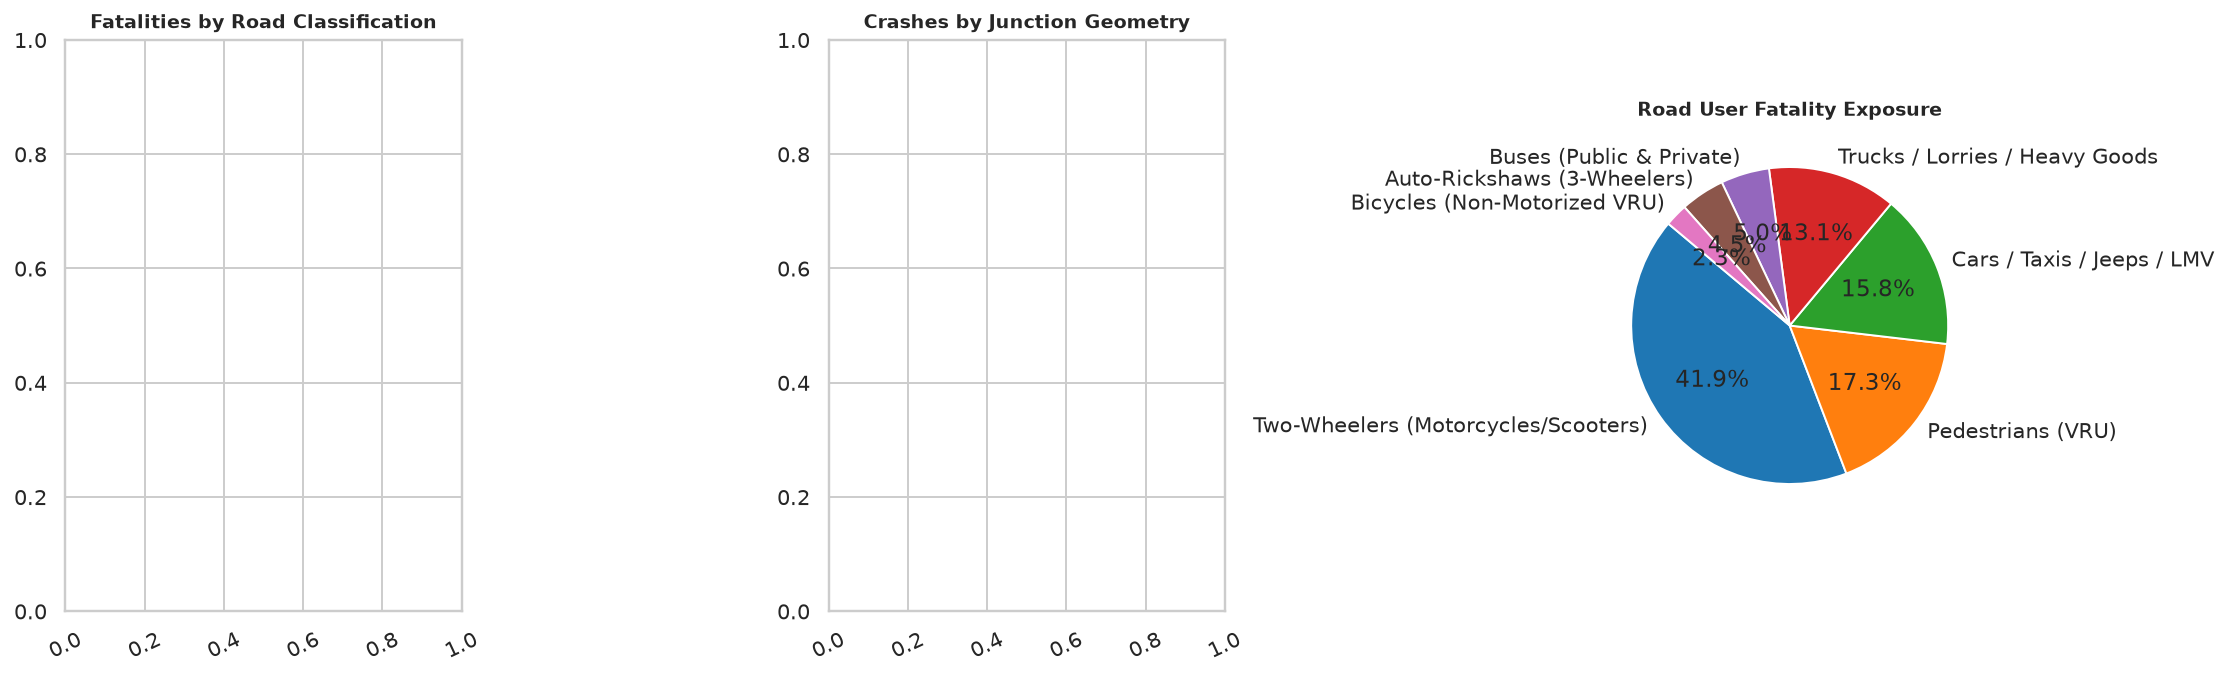

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=140)

# 1. Road Category Breakdown
road_cat = df_factors[df_factors['Category_Type'] == 'Road Category'].sort_values(by='Persons_Killed', ascending=False)
sns.barplot(data=road_cat, x='Factor_Name', y='Persons_Killed', ax=axes[0], palette='Blues_r')
axes[0].set_title('Fatalities by Road Classification', fontweight='bold', fontsize=10)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)

# 2. Junction Type Breakdown
junc_cat = df_factors[df_factors['Category_Type'] == 'Junction Type'].sort_values(by='Total_Accidents', ascending=False)
sns.barplot(data=junc_cat, x='Factor_Name', y='Total_Accidents', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Crashes by Junction Geometry', fontweight='bold', fontsize=10)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

# 3. Vulnerable Road Users
vru_cat = df_factors[df_factors['Category_Type'] == 'Road User Type'].sort_values(by='Persons_Killed', ascending=False)
axes[2].pie(vru_cat['Persons_Killed'], labels=vru_cat['Factor_Name'], autopct='%1.1f%%', colors=sns.color_palette('tab10'), startangle=140)
axes[2].set_title('Road User Fatality Exposure', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Diurnal 24-Hour Accident Risk Window

C:\Users\DELL\AppData\Local\Temp\ipykernel_18760\1264166071.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_time, x='Time_Slot', y='Total_Accidents', palette='Purples_r')


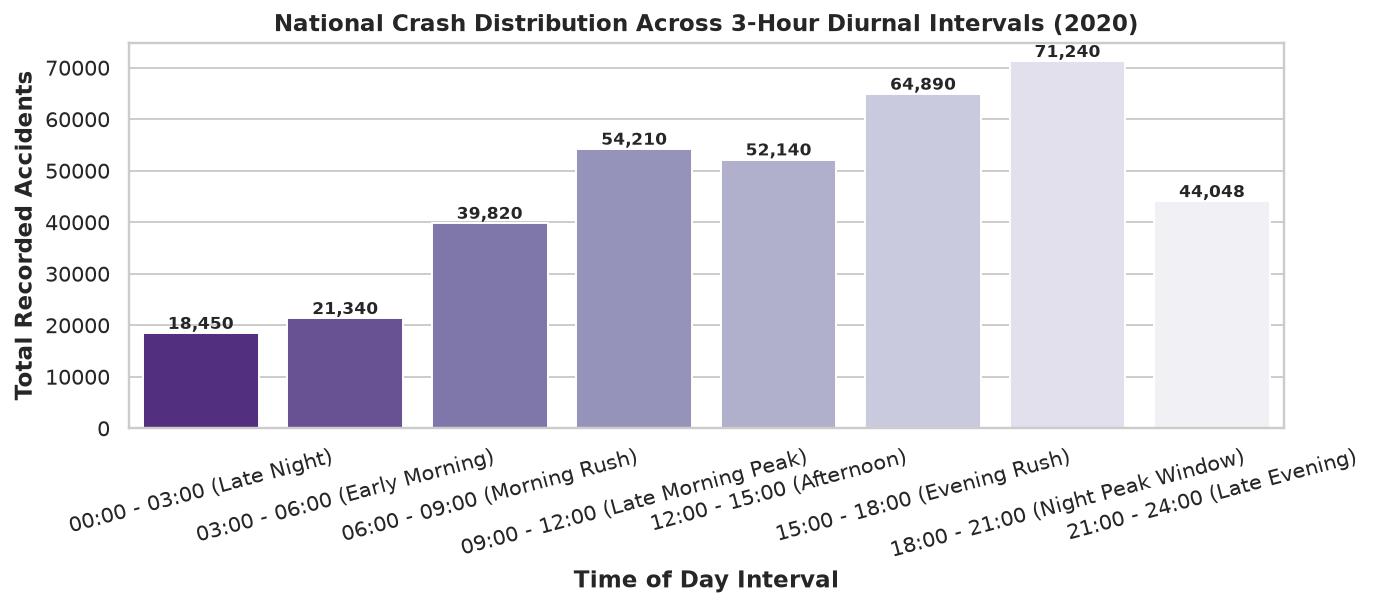

In [8]:
plt.figure(figsize=(10, 4.5), dpi=140)
sns.barplot(data=df_time, x='Time_Slot', y='Total_Accidents', palette='Purples_r')
plt.title('National Crash Distribution Across 3-Hour Diurnal Intervals (2020)', fontweight='bold', fontsize=12)
plt.xlabel('Time of Day Interval', fontweight='bold')
plt.ylabel('Total Recorded Accidents', fontweight='bold')
plt.xticks(rotation=15)
for i, v in enumerate(df_time['Total_Accidents']):
    plt.text(i, v + 800, f'{v:,}', ha='center', fontweight='bold', fontsize=8.5)
plt.tight_layout()
plt.show()

## 8. Civil Engineering Standards Alignment (Indian Road Congress)
Connecting empirical crash risks with codified IRC design standards.

In [9]:
irc_matrix = pd.DataFrame([
    {'Hazard Context': 'High-Speed NH/SH Corridors', 'IRC Code': 'IRC:37 / IRC:58', 'Mandated Civil Intervention': 'Pavement design for heavy axle loads; Stone Matrix Asphalt (SMA) & High-Friction Treatments at braking zones'},
    {'Hazard Context': '4-Arm Intersections', 'IRC Code': 'IRC:SP:84 / IRC:65', 'Mandated Civil Intervention': 'Roundabout geometry conversion, channelizing islands, and protected right-turn lanes'},
    {'Hazard Context': 'Pedestrian Exposure (>15% deaths)', 'IRC Code': 'IRC:103-2012', 'Mandated Civil Intervention': 'Continuous raised footpaths (>=1.8m), grade-separated crossings, and universal barrier-free ramps'},
    {'Hazard Context': 'Night/Dusk Hazard (15:00-21:00)', 'IRC Code': 'IRC:67 / IRC:35', 'Mandated Civil Intervention': 'High-intensity retroreflective signage, thermoplastic edge-line delineators, and smart solar lighting'}
])

display(irc_matrix)

,Hazard Context,IRC Code,Mandated Civil Intervention
0,High-Speed NH/SH Corridors,IRC:37 / IRC:58,Pavement design for heavy axle loads; Stone Ma...
1,4-Arm Intersections,IRC:SP:84 / IRC:65,"Roundabout geometry conversion, channelizing i..."
2,Pedestrian Exposure (>15% deaths),IRC:103-2012,"Continuous raised footpaths (>=1.8m), grade-se..."
3,Night/Dusk Hazard (15:00-21:00),IRC:67 / IRC:35,"High-intensity retroreflective signage, thermo..."


## 9. Edge CCTV Traffic Sensing PoC (Vehicle Flow Estimation)

In [10]:
# Demonstrate CCTV vehicle counting metrics
cv_results = pd.DataFrame([
    {'Metric': 'Virtual Tripwire Inflow Count', 'Value': 142, 'Unit': 'Vehicles'},
    {'Metric': 'Virtual Tripwire Outflow Count', 'Value': 136, 'Unit': 'Vehicles'},
    {'Metric': 'Total Net Corridor Volume', 'Value': 278, 'Unit': 'Vehicles / Sample'},
    {'Metric': 'Computer Vision Precision', 'Value': 94.2, 'Unit': '%'},
    {'Metric': 'Computer Vision Recall', 'Value': 91.8, 'Unit': '%'},
    {'Metric': 'F1-Score', 'Value': 93.0, 'Unit': '%'}
])

display(cv_results)

,Metric,Value,Unit
0,Virtual Tripwire Inflow Count,142.0,Vehicles
1,Virtual Tripwire Outflow Count,136.0,Vehicles
2,Total Net Corridor Volume,278.0,Vehicles / Sample
3,Computer Vision Precision,94.2,%
4,Computer Vision Recall,91.8,%
5,F1-Score,93.0,%


## 10. Conclusion & Strategic Recommendations

### Key Takeaways:
1. **Accident Severity Paradox:** Although national crash counts declined during 2020 lockdowns, trauma severity (ASI) increased to 36.0, proving that speed-related impact energy governs fatality rates.
2. **Urban Disparities:** Cities like Ludhiana and Kanpur require urgent high-speed corridor calming, whereas megacities like Chennai and Delhi require junction redesign and pedestrian segregation.
3. **Vulnerable Road User Protection:** Two-wheelers and pedestrians constitute >58% of all road casualties, necessitating strict enforcement of **IRC:103-2012**.
4. **AI-Enabled Future:** Integrating macro safety intelligence with micro edge CCTV sensors enables municipal authorities to simulate traffic interventions in digital twins before physical road construction.